In [1]:
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
# torch.multiprocessing.set_start_method('spawn', force=True)
import time
import importlib
import torch.optim as optim
from torchsummary import summary
import os
import statistics

os.chdir("../")
from src.data_preparation import SimulatedDataset, collate_function, load_real_data
from src.transformers import MiniTransformer
import src.transformers as transformerFunctions
from src.transformers import init_weights_recursive
from src.transformers import print_parameters
from src.transformers import create_custom_mask, create_distance_to_end_matrix, create_pairwise_distance_matrix
from src.evaluation import calculate_bench1_loss, calculate_bench2_loss, calculate_repeat_loss, calculate_regression_loss, evaluate_mini_transformer
from src.statistical_testing import statistical_testing, print_p_values, plot_context_predindex_pair_effect, get_context_predindex_pair_effect
import torch.autograd.profiler as profiler
from sklearn.model_selection import KFold
device = torch.device("cpu")

In [2]:

if __name__ == '__main__':

    # Hyperparameters
    # data_str = "ghq_b_sum"
    # data_str = "ghq_sum"
    data_str = "simulation"
    batch_size = 1           # Batch size for loading data
    dk = 1                  # d_k
    dv = 1                  # d_v
    nheads = 2             # number of heads
    ncum = 2                 # number of cumulants
    maxlen = 10             # maximum length of the sequence
    learning_rate = 1e-3
    lambda_l2 = 1e-3
    EPOCHS = 200
    target_sample_size = 16
    nrepp = 1
    
    # Set the random seed for reproducibility
    torch.manual_seed(42)
    
    n = 50
    p = 4
    maxlen = 10
    # Create Dataset and DataLoader
    train_dataset = SimulatedDataset(n, p, maxlen=maxlen, device = device).data
    eval_dataset = SimulatedDataset(1000, p, maxlen=4, device = device).data
    predindex = 2
    


    n = len(train_dataset)
    p = train_dataset[0].shape[1]
    print("Sample size: ", len(train_dataset), "\n")
    



    mask = create_custom_mask(maxlen, device)
    distance_to_end_matrix = create_distance_to_end_matrix(maxlen, device)
    pairwise_distance_matrix = create_pairwise_distance_matrix(maxlen, device)


    dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_function,  num_workers=0)
    
    model = MiniTransformer(p, nheads, dk, dv, ncum, mask, pairwise_distance_matrix, distance_to_end_matrix,  device)

    model.apply(init_weights_recursive)
    model.to(device)

    # model = torch.compile(model)
    # Start the timer
    start_time = time.time()

    # Define optimizer
    # optimizer = optim.Adam(model.parameters(), lr= learning_rate, weight_decay=lambda_l2)
    optimizer = optim.Adam(model.parameters(), lr= learning_rate)
    
    print("Number of Parameters", transformerFunctions.count_parameters(model))
    
    run_path = transformerFunctions.train_mini_transformer(model, dataloader, optimizer, lambda_l2, EPOCHS, device)


    # End the timer
    end_time = time.time()

    # Calculate and print the execution time
    execution_time = end_time - start_time 
    print(f"Execution time: {execution_time:.6f} seconds")




Sample size:  50 

Number of Parameters 48
EPOCH 1:
avg_loss: 9.49312
EPOCH 2:
avg_loss: 8.77655
EPOCH 3:
avg_loss: 7.98014
EPOCH 4:
avg_loss: 6.86531
EPOCH 5:
avg_loss: 5.48767
EPOCH 6:
avg_loss: 4.32652
EPOCH 7:
avg_loss: 3.78415
EPOCH 8:
avg_loss: 3.64859
EPOCH 9:
avg_loss: 3.61485
EPOCH 10:
avg_loss: 3.59285
EPOCH 11:
avg_loss: 3.57800
EPOCH 12:
avg_loss: 3.56410
EPOCH 13:
avg_loss: 3.55441
EPOCH 14:
avg_loss: 3.54007
EPOCH 15:
avg_loss: 3.52707
EPOCH 16:
avg_loss: 3.51475
EPOCH 17:
avg_loss: 3.50692
EPOCH 18:
avg_loss: 3.49638
EPOCH 19:
avg_loss: 3.48545
EPOCH 20:
avg_loss: 3.47408
EPOCH 21:
avg_loss: 3.46507
EPOCH 22:
avg_loss: 3.45657
EPOCH 23:
avg_loss: 3.44617
EPOCH 24:
avg_loss: 3.43874
EPOCH 25:
avg_loss: 3.42991
EPOCH 26:
avg_loss: 3.42373
EPOCH 27:
avg_loss: 3.41482
EPOCH 28:
avg_loss: 3.40915
EPOCH 29:
avg_loss: 3.40424
EPOCH 30:
avg_loss: 3.39299
EPOCH 31:
avg_loss: 3.38782
EPOCH 32:
avg_loss: 3.38395
EPOCH 33:
avg_loss: 3.38064
EPOCH 34:
avg_loss: 3.37141
EPOCH 35:
avg_

In [3]:
avepval, stdpval, context, targetall = statistical_testing(model, train_dataset, p, predindex, nrepp, target_sample_size)

Repetition 1/1
Processed 100000000 combinations out of approximately 4294967296
Processed 200000000 combinations out of approximately 4294967296
Processed 300000000 combinations out of approximately 4294967296
Processed 400000000 combinations out of approximately 4294967296
Processed 500000000 combinations out of approximately 4294967296
Processed 600000000 combinations out of approximately 4294967296
Processed 700000000 combinations out of approximately 4294967296
Processed 800000000 combinations out of approximately 4294967296
Processed 900000000 combinations out of approximately 4294967296
Processed 1000000000 combinations out of approximately 4294967296
Processed 1100000000 combinations out of approximately 4294967296
Processed 1200000000 combinations out of approximately 4294967296
Processed 1300000000 combinations out of approximately 4294967296
Processed 1400000000 combinations out of approximately 4294967296
Processed 1500000000 combinations out of approximately 4294967296
Proc

In [22]:
print_p_values(avepval, stdpval)

Variable 1: 0.0096 ± 0.00
Variable 2: 0.0000 ± 0.00
Variable 3: 0.0000 ± 0.00
Variable 4: 0.4664 ± 0.00


In [8]:
context_predindex_pair_effect = get_context_predindex_pair_effect(model, p, context, targetall, nrepp)    

Repetition 1/1


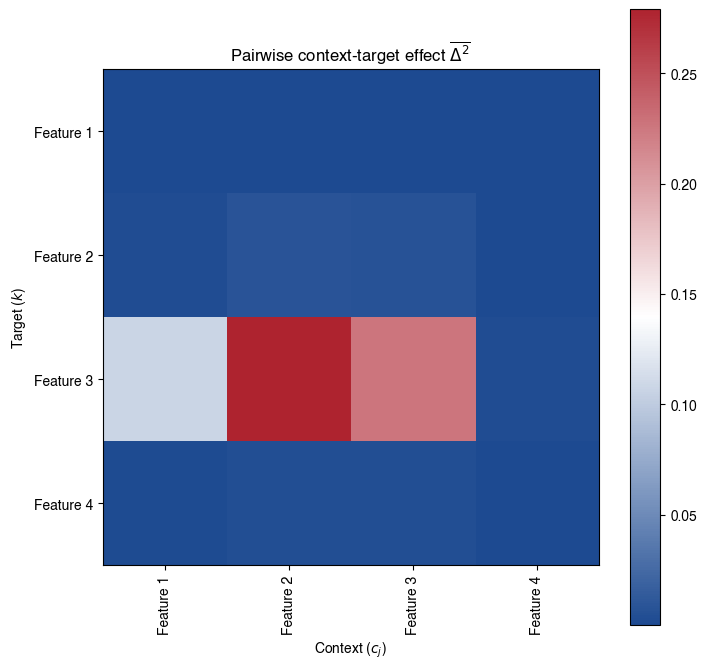

In [9]:
plot_context_predindex_pair_effect(context_predindex_pair_effect, data_str, run_path)